# 03 — Extended Simplex Model

Loads the pre-trained simplex backbone (784→128→64) and extends it with
additional hidden layers + regularization before the classification head.

**Architecture:** frozen backbone → new trainable layers → classifier

```
[FROZEN]  fc1: 784→128  (BN, ReLU, Dropout)
[FROZEN]  fc2: 128→64   (LN, ReLU, Dropout)
[NEW]     fc3: 64→48    (BN, ReLU, Dropout)
[NEW]     fc4: 48→32    (LN, ReLU, Dropout)
[NEW]     fc5: 32→10    (output)
```

**Key question:** Do additional trainable layers on top of frozen simplex
features improve accuracy, and how do the new representations reshape the
clustering geometry?

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from scripts.viz_export import ExperimentTracker

import numpy as np
from sklearn.metrics import silhouette_score

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch {torch.__version__}")
device = torch.device("cpu")

/Users/morgancooper/miniconda3/envs/nnpo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


## 2. Load Simplex Backbone

In [3]:
ckpt_path = os.path.join(PROJECT_ROOT, "experimentation", "02_clustering_pretrain", "checkpoints", "simplex_backbone.pt")
ckpt = torch.load(ckpt_path, map_location=device)

print(f"Loaded: {ckpt_path}")
print(f"Architecture: {ckpt['architecture']}")
print(f"Pre-train hyperparameters: {ckpt['hyperparameters']}")
print(f"Simplex targets shape: {ckpt['simplex_targets'].shape}")

Loaded: /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/02_clustering_pretrain/checkpoints/simplex_backbone.pt
Architecture: {'fc1': [784, 128], 'fc2': [128, 64]}
Pre-train hyperparameters: {'target_scale': 5.0, 'lr': 0.001, 'weight_decay': 0.0001, 'l1_lambda': 0.0001, 'dropout': 0.3, 'epochs': 10}
Simplex targets shape: torch.Size([10, 64])


## 3. Define Extended Model

In [4]:
# --- Hyperparameters ---
LR = 0.001
WEIGHT_DECAY = 1e-4
L1_LAMBDA = 1e-4
DROPOUT = 0.3
NUM_EPOCHS = 5
CHECKPOINT_EVERY = 10   # Save checkpoint every N batches
FINE_TUNE_BACKBONE = False  # Set True to unfreeze and fine-tune the backbone

# --- LR Scheduler (ReduceLROnPlateau) ---
SCHEDULER_PATIENCE = 2     # Epochs to wait before reducing LR
SCHEDULER_FACTOR = 0.5     # Multiply LR by this on plateau
SCHEDULER_MIN_LR = 1e-6    # Floor for LR


class ExtendedSimplexNet(nn.Module):
    """Frozen simplex backbone + new trainable hidden layers + classifier.

    Backbone (from simplex pre-training):
        fc1: 784→128 (BN, ReLU, Dropout)
        fc2: 128→64  (LN, ReLU, Dropout)

    New layers:
        fc3: 64→48   (BN, ReLU, Dropout)
        fc4: 48→32   (LN, ReLU, Dropout)
        fc5: 32→10   (output)
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        # --- Backbone (loaded from checkpoint) ---
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(dropout)

        # --- New trainable layers ---
        self.fc3 = nn.Linear(64, 48)
        self.bn3 = nn.BatchNorm1d(48)
        self.drop3 = nn.Dropout(dropout)
        self.fc4 = nn.Linear(48, 32)
        self.ln4 = nn.LayerNorm(32)
        self.drop4 = nn.Dropout(dropout)
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        # Backbone
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        # New layers
        x = self.drop3(torch.relu(self.bn3(self.fc3(x))))
        x = self.drop4(torch.relu(self.ln4(self.fc4(x))))
        x = self.fc5(x)
        return x


model = ExtendedSimplexNet(dropout=DROPOUT).to(device)

# Load pre-trained backbone weights
backbone_state = ckpt["model_state_dict"]
load_result = model.load_state_dict(backbone_state, strict=False)
print(f"Loaded backbone weights")
print(f"  Missing keys (new layers, expected): {load_result.missing_keys}")
print(f"  Unexpected keys: {load_result.unexpected_keys}")

# Freeze backbone unless fine-tuning
if not FINE_TUNE_BACKBONE:
    for name, param in model.named_parameters():
        if any(name.startswith(layer) for layer in ["fc1.", "bn1.", "fc2.", "ln2."]):
            param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nFine-tune backbone: {FINE_TUNE_BACKBONE}")
print(f"Trainable: {trainable:,} / {total:,} params")
print(f"LR schedule: ReduceLROnPlateau(patience={SCHEDULER_PATIENCE}, factor={SCHEDULER_FACTOR}, min_lr={SCHEDULER_MIN_LR})")
print(model)

Loaded backbone weights
  Missing keys (new layers, expected): ['fc3.weight', 'fc3.bias', 'bn3.weight', 'bn3.bias', 'bn3.running_mean', 'bn3.running_var', 'fc4.weight', 'fc4.bias', 'ln4.weight', 'ln4.bias', 'fc5.weight', 'fc5.bias']
  Unexpected keys: []

Fine-tune backbone: False
Trainable: 5,178 / 114,298 params
LR schedule: ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-06)
ExtendedSimplexNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=48, bias=True)
  (bn3): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=48, out_features=32,

## 4. Pick Input Samples & Viz Samples

In [5]:
# 5 input samples: one per distinct digit (first 5 unique)
seen_labels = set()
five_images, five_labels = [], []
for img, label in full_train_dataset:
    if label not in seen_labels:
        five_images.append(img)
        five_labels.append(int(label))
        seen_labels.add(label)
    if len(seen_labels) == 5:
        break
five_images = torch.stack(five_images)
print(f"Input samples: labels={five_labels}, shape={five_images.shape}")

# 500 viz samples: 50 per class
viz_images, viz_labels = [], []
class_counts = {c: 0 for c in range(10)}
for img, label in full_train_dataset:
    label = int(label)
    if class_counts[label] < 50:
        viz_images.append(img)
        viz_labels.append(label)
        class_counts[label] += 1
    if all(v >= 50 for v in class_counts.values()):
        break
viz_images = torch.stack(viz_images)
print(f"Viz samples: {len(viz_labels)} total, shape={viz_images.shape}")

Input samples: labels=[5, 0, 4, 1, 9], shape=torch.Size([5, 784])
Viz samples: 500 total, shape=torch.Size([500, 784])


## 5. Create Tracker

In [6]:
tracker = ExperimentTracker(
    run_id="simplex_extended",
    model_name="Extended Simplex Net",
    description="Simplex backbone + 2 new hidden layers (64\u219248\u219232\u219210)",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "fine_tune_backbone": FINE_TUNE_BACKBONE,
        "frozen_layers": [] if FINE_TUNE_BACKBONE else ["fc1", "bn1", "fc2", "ln2"],
        "scheduler": "ReduceLROnPlateau",
        "scheduler_patience": SCHEDULER_PATIENCE,
        "scheduler_factor": SCHEDULER_FACTOR,
        "scheduler_min_lr": SCHEDULER_MIN_LR,
    },
    model=model,
)

tracker.track("input", size=784)
tracker.track("hidden_1", model.fc1, size=128)
tracker.track("hidden_2", model.fc2, size=64)
tracker.track("hidden_3", model.fc3, size=48)
tracker.track("hidden_4", model.fc4, size=32)
tracker.track("output", model.fc5, size=10)

tracker.set_input_samples(five_images, five_labels)
tracker.set_viz_samples(viz_images, viz_labels)
tracker.enable_gradient_capture()
tracker.enable_loss_landscape()

ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/simplex_extended_v1


## 6. Train

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=SCHEDULER_PATIENCE,
                              factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR)

def evaluate(loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

# Training history for plotting
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "val_accuracy": [], "test_accuracy": [], "lr": [],
}

step = 0
global_batch = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(batch_x)
        l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
        loss = criterion(output, batch_y) + L1_LAMBDA * l1_norm

        loss.backward()
        tracker.capture_gradients()
        optimizer.step()

        running_loss += loss.item()
        global_batch += 1

        if global_batch % CHECKPOINT_EVERY == 0:
            val_loss, val_acc = evaluate(val_loader)
            _, test_acc = evaluate(test_loader)
            tracker.compute_loss_landscape(batch_x, batch_y, criterion)
            tracker.save_checkpoint(step=step, epoch=epoch, metrics={
                "train_loss": running_loss / (batch_idx + 1),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
                "lr": optimizer.param_groups[0]["lr"],
            })
            step += 1
            model.train()

    # End-of-epoch metrics
    epoch_train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    _, test_acc = evaluate(test_loader)
    current_lr = optimizer.param_groups[0]["lr"]

    # Step scheduler on val loss
    scheduler.step(val_loss)

    # Record history
    history["epoch"].append(epoch)
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["test_accuracy"].append(test_acc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"val_acc={val_acc:.4f}, test_acc={test_acc:.4f}, lr={current_lr:.6f}")

print(f"\nTraining complete \u2014 {step} checkpoints saved")

  step_000.json (epoch=0, loss=1.8970, acc=0.5814, size=2.9MB)
  step_001.json (epoch=0, loss=1.4317, acc=0.9316, size=2.9MB)
  step_002.json (epoch=0, loss=1.1382, acc=0.9557, size=2.9MB)
  step_003.json (epoch=0, loss=0.9417, acc=0.9574, size=2.9MB)
  step_004.json (epoch=0, loss=0.8005, acc=0.9583, size=2.9MB)
  step_005.json (epoch=0, loss=0.6853, acc=0.9587, size=2.9MB)
  step_006.json (epoch=0, loss=0.5911, acc=0.9593, size=2.9MB)
  step_007.json (epoch=0, loss=0.5166, acc=0.9587, size=2.9MB)
  step_008.json (epoch=0, loss=0.4557, acc=0.9590, size=2.9MB)
Epoch 0: train_loss=1.6137, val_loss=0.4354, val_acc=0.9593, test_acc=0.9646, lr=0.001000
  step_009.json (epoch=1, loss=0.4078, acc=0.9590, size=2.9MB)
  step_010.json (epoch=1, loss=0.3676, acc=0.9594, size=2.9MB)
  step_011.json (epoch=1, loss=0.3363, acc=0.9597, size=2.9MB)
  step_012.json (epoch=1, loss=0.3122, acc=0.9593, size=2.9MB)
  step_013.json (epoch=1, loss=0.2932, acc=0.9593, size=2.9MB)
  step_014.json (epoch=1, lo

## 7. Training Curves

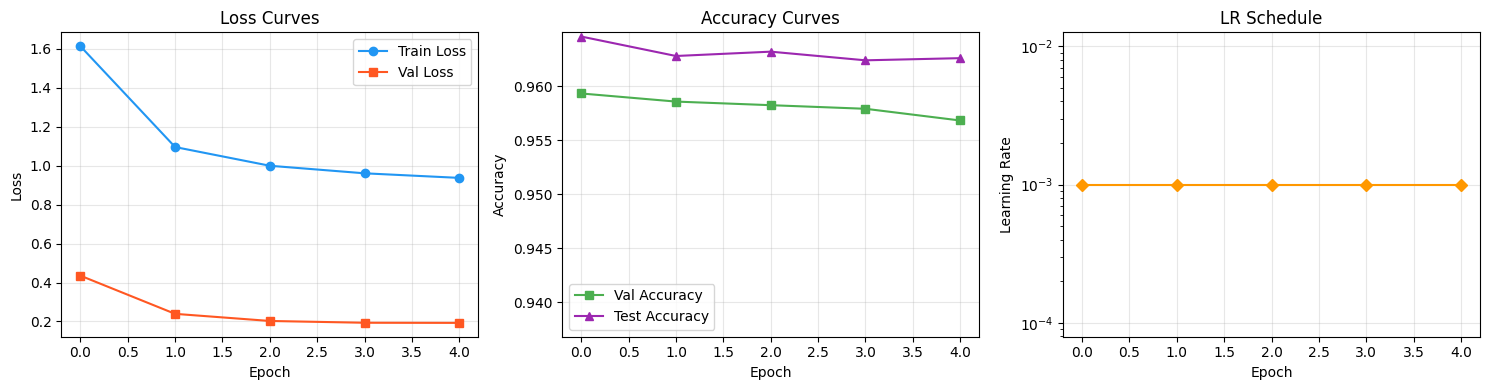

Epoch  Train Loss  Val Loss  Val Acc  Test Acc         LR
----------------------------------------------------------
    0      1.6137    0.4354   0.9593    0.9646   0.001000
    1      1.0958    0.2393   0.9586    0.9628   0.001000
    2      0.9997    0.2027   0.9583    0.9632   0.001000
    3      0.9609    0.1935   0.9579    0.9624   0.001000
    4      0.9374    0.1929   0.9568    0.9626   0.001000


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = history["epoch"]

# --- Loss ---
ax = axes[0]
ax.plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax.plot(epochs, history["val_loss"], "s-", label="Val Loss", color="#FF5722")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Accuracy ---
ax = axes[1]
ax.plot(epochs, history["val_accuracy"], "s-", label="Val Accuracy", color="#4CAF50")
ax.plot(epochs, history["test_accuracy"], "^-", label="Test Accuracy", color="#9C27B0")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=max(0, min(history["val_accuracy"]) - 0.02))

# --- Learning Rate ---
ax = axes[2]
ax.plot(epochs, history["lr"], "D-", color="#FF9800")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>9} {'Val Acc':>8} {'Test Acc':>9} {'LR':>10}")
print("-" * 58)
for i, ep in enumerate(epochs):
    print(f"{ep:>5d} {history['train_loss'][i]:>11.4f} {history['val_loss'][i]:>9.4f} "
          f"{history['val_accuracy'][i]:>8.4f} {history['test_accuracy'][i]:>9.4f} {history['lr'][i]:>10.6f}")

In [9]:
tracker.finalize()
print(f"Run: {tracker.run_id}")

# Final evaluation
val_loss, val_acc = evaluate(val_loader)
test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal val accuracy:  {val_acc:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

# Silhouette score on test set hidden activations
hidden_acts, hidden_labels = [], []
hook_out = {}
def _hook(module, inp, out):
    hook_out['act'] = inp[0].detach()
handle = model.fc5.register_forward_hook(_hook)
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        model(x)
        hidden_acts.append(hook_out['act'].numpy())
        hidden_labels.append(y.numpy())
handle.remove()

X_hidden = np.concatenate(hidden_acts)
y_hidden = np.concatenate(hidden_labels)
n_sil = min(5000, len(X_hidden))
idx = np.random.RandomState(42).choice(len(X_hidden), n_sil, replace=False)
sil = silhouette_score(X_hidden[idx], y_hidden[idx])
print(f"\nSilhouette score (test, {X_hidden.shape[1]}D hidden): {sil:.4f}")

Finalized run 'simplex_extended_v1' with 47 checkpoints
Run: simplex_extended_v1

Final val accuracy:  0.9568
Final test accuracy: 0.9626

Silhouette score (test, 32D hidden): 0.7506
